### LOAD CLEAN DF

In [1]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path("..")
PROCESSED_DIR = BASE_DIR / "Data" / "Processed_Data"

df_medidata = pd.read_parquet(PROCESSED_DIR / "df_medidata.parquet")

print("Loaded:", df_medidata.shape)
df_medidata.head()

Loaded: (1178407, 20)


,Rndrng_Prvdr_CCN,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_City,Rndrng_Prvdr_St,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_RUCA,Rndrng_Prvdr_RUCA_Desc,DRG_Cd,DRG_Desc,Tot_Dschrgs,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt,Avg_Mdcr_Pymt_Amt,Data_Year,GNRL_CNTL_TYPE_CD,CRTFD_BED_CNT,BED_CNT,Ownership_Type,ownership_individual,DRG_Weight
0,10001,Southeast Alabama Medical Center,Dothan,1108 Ross Clark Circle,AL,1.0,Metropolitan area core: primary flow within an...,23,CRANIOTOMY WITH MAJOR DEVICE IMPLANT OR ACUTE ...,32,126083.18750,26993.156250,25320.750000,2017,8,420.0,420.0,Government,County,5.3762
1,10001,Southeast Alabama Medical Center,Dothan,1108 Ross Clark Circle,AL,1.0,Metropolitan area core: primary flow within an...,25,CRANIOTOMY AND ENDOVASCULAR INTRACRANIAL PROCE...,31,115948.41940,21662.225810,20814.032260,2017,8,420.0,420.0,Government,County,4.2413
2,10001,Southeast Alabama Medical Center,Dothan,1108 Ross Clark Circle,AL,1.0,Metropolitan area core: primary flow within an...,37,EXTRACRANIAL PROCEDURES WITH MCC,13,78837.30769,16666.615390,14301.230770,2017,8,420.0,420.0,Government,County,3.0795
3,10001,Southeast Alabama Medical Center,Dothan,1108 Ross Clark Circle,AL,1.0,Metropolitan area core: primary flow within an...,38,EXTRACRANIAL PROCEDURES WITH CC,17,56492.82353,8577.000000,6767.470588,2017,8,420.0,420.0,Government,County,1.5762
4,10001,Southeast Alabama Medical Center,Dothan,1108 Ross Clark Circle,AL,1.0,Metropolitan area core: primary flow within an...,39,EXTRACRANIAL PROCEDURES WITHOUT CC/MCC,51,45253.01961,6094.803922,4985.235294,2017,8,420.0,420.0,Government,County,1.0818


In [2]:
df_medidata["Data_Year"].value_counts().sort_index()


Data_Year
2017    196086
2018    192069
2019    187719
2020    158375
2021    151989
2022    145742
2023    146427
Name: count, dtype: int64

## PART 1 - ***SUMMARY STATISTICS***

In [3]:
df_medidata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1178407 entries, 0 to 1178406
Data columns (total 20 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Rndrng_Prvdr_CCN           1178407 non-null  int64  
 1   Rndrng_Prvdr_Org_Name      1178407 non-null  object 
 2   Rndrng_Prvdr_City          1178407 non-null  object 
 3   Rndrng_Prvdr_St            1178407 non-null  object 
 4   Rndrng_Prvdr_State_Abrvtn  1178407 non-null  object 
 5   Rndrng_Prvdr_RUCA          1178407 non-null  float64
 6   Rndrng_Prvdr_RUCA_Desc     1178407 non-null  object 
 7   DRG_Cd                     1178407 non-null  int64  
 8   DRG_Desc                   1178407 non-null  object 
 9   Tot_Dschrgs                1178407 non-null  int64  
 10  Avg_Submtd_Cvrd_Chrg       1178407 non-null  float64
 11  Avg_Tot_Pymt_Amt           1178407 non-null  float64
 12  Avg_Mdcr_Pymt_Amt          1178407 non-null  float64
 13  Data_Year   

### Qualitative data Summary

In [4]:
df_medidata.describe(exclude="number")
#Identify key categorical cols

,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_City,Rndrng_Prvdr_St,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_RUCA_Desc,DRG_Desc,GNRL_CNTL_TYPE_CD,Ownership_Type,ownership_individual
count,1178407,1178407,1178407,1178407,1178407,1178407,1178407,1178407,1178407
unique,4073,1955,3549,51,15,622,17,3,9
top,Methodist Hospital,New York,525 East 68th Street,CA,Metropolitan area core: primary flow within an...,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,2,For-Profit,Partnership
freq,3094,10006,2626,96181,1008770,19303,618169,856516,661935


### Quantitative data Summary

***Summary Statistics***

To understand the overall distribution and scale of inpatient utilization and financial variables, summary statistics were computed for key measures related to discharges, charges, and payments.

The following variables were analyzed:
- Total Discharges (`Tot_Dschrgs`)
- Average Submitted Covered Charges (`Avg_Submtd_Cvrd_Chrg`)
- Average Total Payment Amount (`Avg_Tot_Pymt_Amt`)
- Average Medicare Payment Amount (`Avg_Mdcr_Pymt_Amt`)
- Certified Bed Count (`CRTFD_BED_CNT`)
- Total Bed Count (`BED_CNT`)

For each variable, the mean, median, minimum, maximum, and range were calculated. 

In [5]:
Numeric_cols = df_medidata.select_dtypes(include="number").columns
key_NumericCols=[
    "Tot_Dschrgs",
    "Avg_Submtd_Cvrd_Chrg",
    "Avg_Tot_Pymt_Amt",
    "Avg_Mdcr_Pymt_Amt",
    "CRTFD_BED_CNT",
    "BED_CNT",
]
summary_Stats=df_medidata[key_NumericCols].describe().round(4)
summary_Stats = summary_Stats.rename(index={"50%": "median"})
summary_Stats.loc["range"] = (summary_Stats.loc["max"] - summary_Stats.loc["min"]).round(4)

# summary_clean = df_medidata[key_NumericCols].agg(
#     ["mean", "median", "min", "max"]
# ).round(4)

# summary_clean.loc["range"] = (
#     summary_clean.loc["max"] - summary_clean.loc["min"]
# ).round(4)

summary_Stats

,Tot_Dschrgs,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt,Avg_Mdcr_Pymt_Amt,CRTFD_BED_CNT,BED_CNT
count,1.178407e+06,1.178407e+06,1.178407e+06,1.178407e+06,1.178407e+06,1.178407e+06
mean,3.596940e+01,7.531559e+04,1.643991e+04,1.379085e+04,4.447039e+02,4.556215e+02
std,5.400600e+01,9.581047e+04,1.823228e+04,1.603071e+04,3.608699e+02,3.637111e+02
min,1.100000e+01,2.262917e+03,1.065091e+03,0.000000e+00,1.000000e+00,1.000000e+00
25%,1.400000e+01,2.897700e+04,7.569098e+03,5.970380e+03,2.150000e+02,2.210000e+02
median,2.100000e+01,4.856575e+04,1.125342e+04,9.314641e+03,3.540000e+02,3.630000e+02
75%,3.700000e+01,8.659173e+04,1.816626e+04,1.520336e+04,5.710000e+02,5.920000e+02
max,4.291000e+03,1.041893e+07,7.617388e+05,7.514790e+05,3.251000e+03,3.251000e+03
range,4.280000e+03,1.041667e+07,7.606737e+05,7.514790e+05,3.250000e+03,3.250000e+03


## PART 2 - ***OUTLIER ANALYSIS***

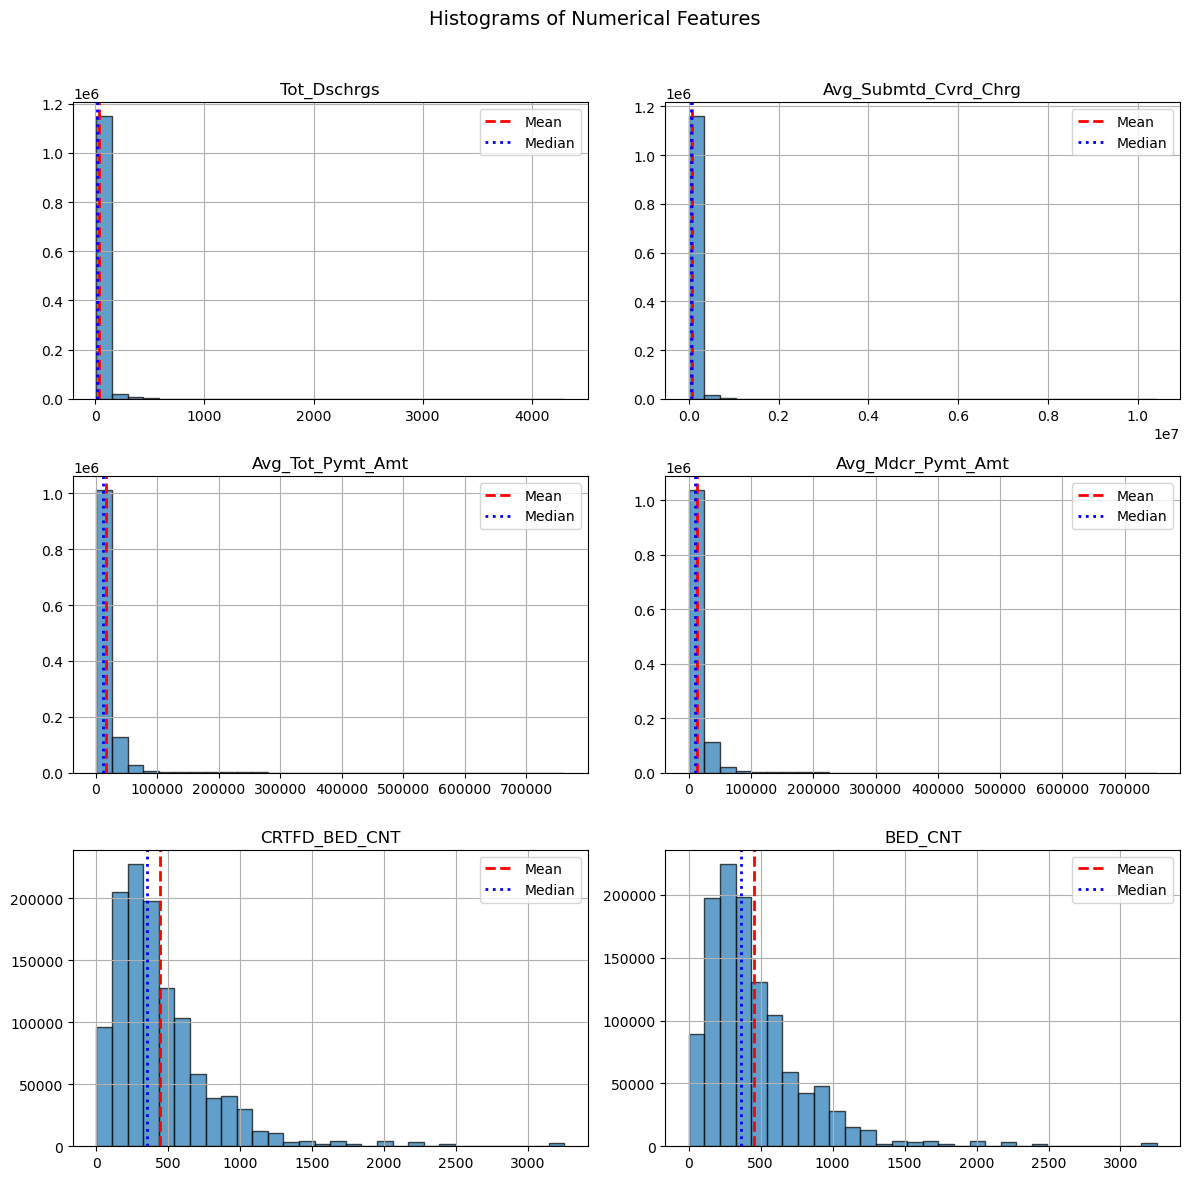

In [6]:
# Histograms 
import os
from matplotlib import pyplot as plt

n_cols = 2
n_rows = (len(key_NumericCols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()
for i, col in enumerate(key_NumericCols):
    ax = axes[i]
    df_medidata[col].hist(ax=ax, bins=30, edgecolor="black", alpha=0.7)
    ax.axvline(df_medidata[col].mean(), color='red', linestyle='dashed', linewidth=2, label='Mean')
    ax.axvline(df_medidata[col].median(), color='blue', linestyle='dotted', linewidth=2, label='Median')
    ax.set_title(col, fontsize=12)
    ax.legend()

# turn off any unused axes
for j in range(len(key_NumericCols), len(axes)):
    axes[j].axis('off')

plt.suptitle("Histograms of Numerical Features", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save for dashboard reuse (before plt.show() clears the figure)
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/eda_histograms.png', dpi=100, bbox_inches='tight')

plt.show()


### **KDE Plot**
Most hospitals have small–to–moderate values, and a few have extremely large values

That creates right-skewed distributions as shown below (A tall spike on the left and a long, flat tail to the right)

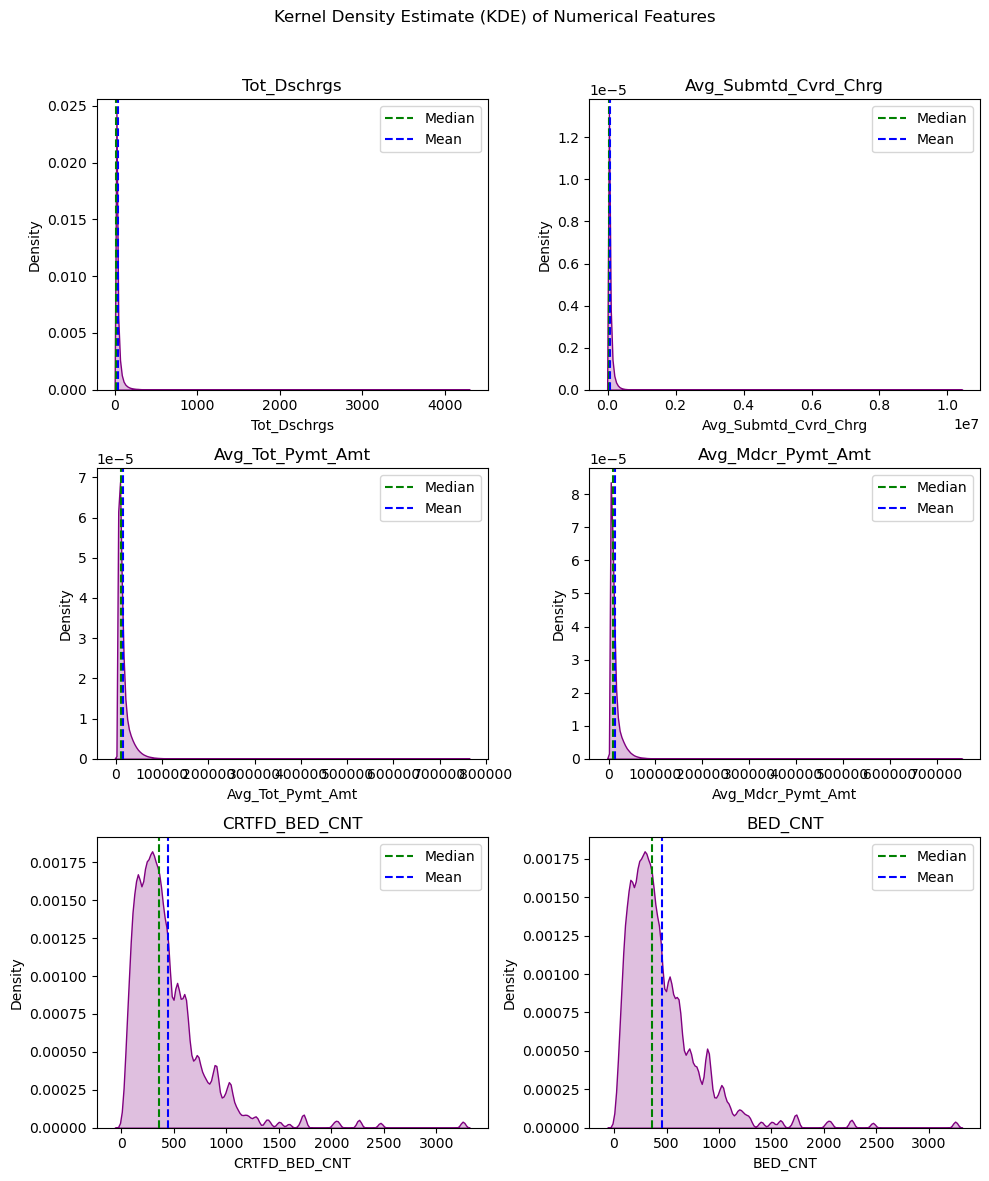

In [7]:
# Numerical features- plots kde
from matplotlib import pyplot as plt
import seaborn as sns

n_cols = 2
n_rows = (len(key_NumericCols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(key_NumericCols):
    ax = axes[i]
    sns.kdeplot(df_medidata[col], ax=ax, fill=True, color="purple")
    ax.set_title(col)
    ax.axvline(df_medidata[col].median(), color='green', linestyle='dashed', label="Median")
    ax.axvline(df_medidata[col].mean(), color='blue', linestyle='dashed', label="Mean")
    ax.legend()

# turn off any unused axes
for j in range(len(key_NumericCols), len(axes)):
    axes[j].axis('off')

plt.suptitle("Kernel Density Estimate (KDE) of Numerical Features", fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### *Insights from KDE Plot*
- Most hospitals discharge tens to hundreds of patients → a few large systems discharge thousands
- Most DRGs cost tens of thousands → a few cost hundreds of thousands
- Most hospitals have <500 beds → a few have 2000–3000+ beds
- Financial variables (Avg_Submtd_Cvrd_Chrg, payments) are more skewed than capacity variables.
Reason: Pricing varies wildly by DRG severity, hospital type, geography, contracts
Beds are constrained physically → less extreme variation

These patterns are expected in healthcare data and reflect real differences in hospital size, case severity, and service intensity. **Outliers were retained, as they represent meaningful operational and financial variation rather than data quality issues**.

### Box plot 

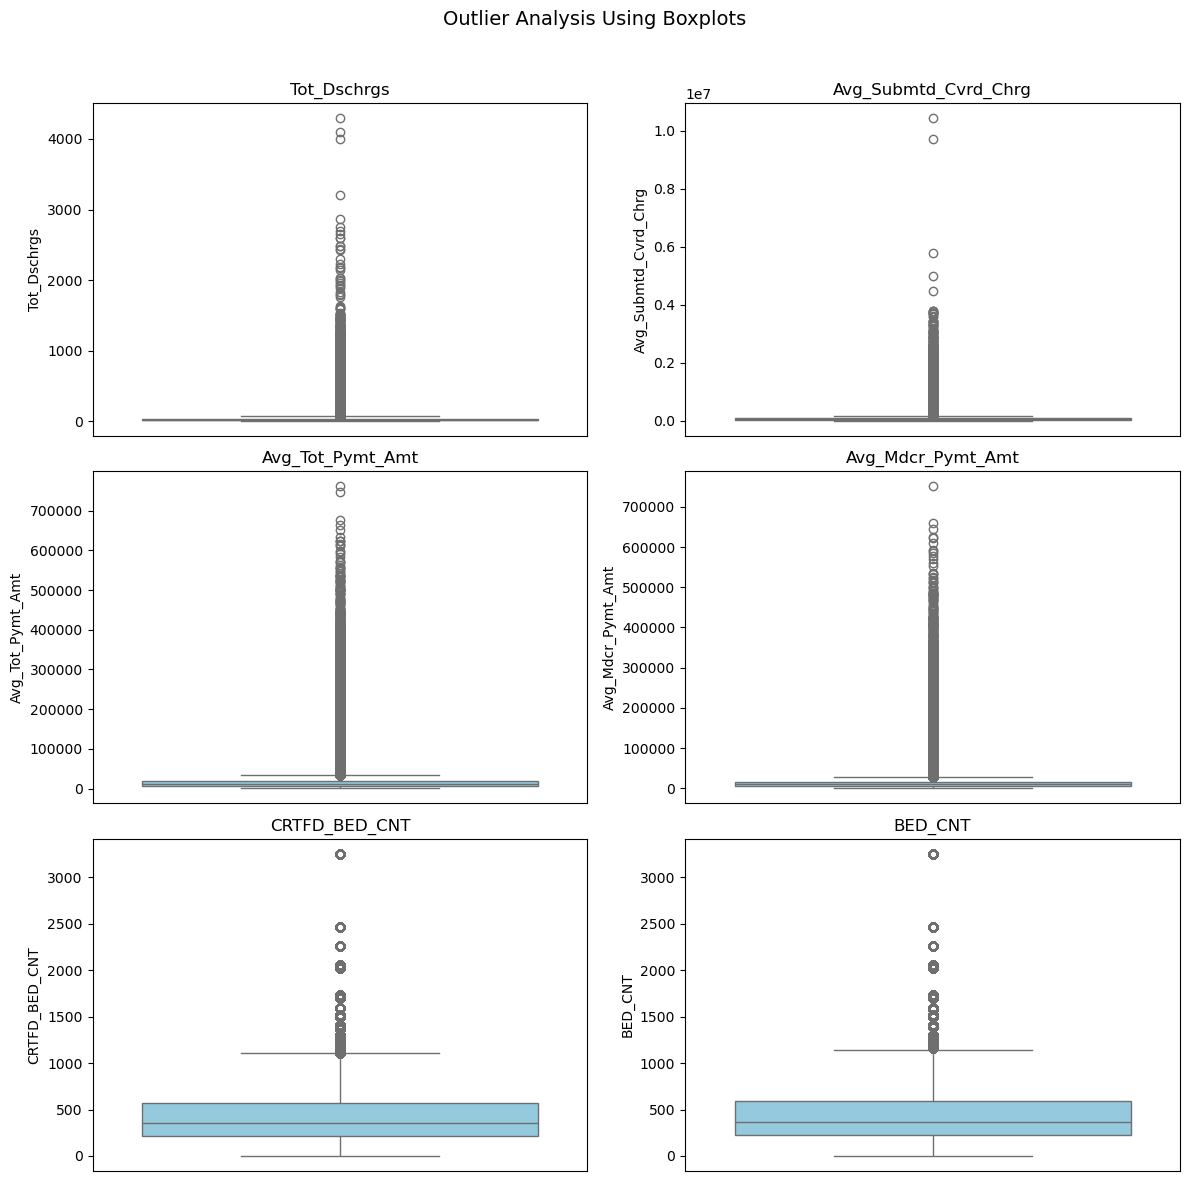

In [8]:
from matplotlib import pyplot as plt
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(key_NumericCols):
    ax = axes[i]
    sns.boxplot(y=df_medidata[col], ax=ax, color="skyblue", showfliers=True)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_xticks([])

# turn off any unused axes
for j in range(len(key_NumericCols), len(axes)):
    axes[j].axis("off")

plt.suptitle("Outlier Analysis Using Boxplots", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### Identify Outliers using the **Interquartile Range (IQR) method**
Note : outliers are identified but not removed

In [9]:
# Identify Outliers using the Interquartile Range (IQR) method
# This defines a reusable function that copies the incoming DataFrame,
# computes IQR-based outliers for the chosen columns, displays the summary,
# and returns the summary DataFrame for later use.

def identify_iqr_outliers(df, cols=None, factor=1.5):
    """Identify outliers using the IQR method.

    Parameters
    - df: pandas DataFrame input
    - cols: list of column names to analyze (defaults to all numeric columns)
    - factor: multiplier for IQR (default 1.5)

    Returns
    - outlier_df: pandas DataFrame summarizing outliers for each column
    """
    df_copy = df.copy()

    if cols is None:
        cols = df_copy.select_dtypes(include="number").columns.tolist()

    outlier_summary = []

    for col in cols:
        Q1 = df_copy[col].quantile(0.25)
        Q3 = df_copy[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - factor * IQR
        upper_bound = Q3 + factor * IQR

        outliers_below = (df_copy[col] < lower_bound).sum()
        outliers_above = (df_copy[col] > upper_bound).sum()
        total_outliers = ((df_copy[col] < lower_bound) | (df_copy[col] > upper_bound)).sum()

        outlier_summary.append({
            "Column": col,
            "Lower outliers": int(outliers_below),
            "Upper outliers": int(outliers_above),
            "Total_Outliers": int(total_outliers),
            "Percent_Outliers": round((int(total_outliers) / len(df_copy)) * 100, 2),
            "Lower bound": lower_bound,
            "Minimum value": df_copy[col].min(),
            "Upper bound": upper_bound,
            "Maximum value": df_copy[col].max()
        })

    outlier_df = pd.DataFrame(outlier_summary)

    from IPython.display import display
    display(outlier_df)

    return outlier_df



outlier_df = identify_iqr_outliers(df_medidata, cols=key_NumericCols)

,Column,Lower outliers,Upper outliers,Total_Outliers,Percent_Outliers,Lower bound,Minimum value,Upper bound,Maximum value
0,Tot_Dschrgs,0,108815,108815,9.23,-20.500000,11.000000,71.500000,4.291000e+03
1,Avg_Submtd_Cvrd_Chrg,0,94482,94482,8.02,-57445.106817,2262.916667,173013.832575,1.041893e+07
2,Avg_Tot_Pymt_Amt,0,107065,107065,9.09,-8326.651786,1065.090909,34062.013294,7.617388e+05
3,Avg_Mdcr_Pymt_Amt,0,109983,109983,9.33,-7879.097251,0.000000,29052.841571,7.514790e+05
4,CRTFD_BED_CNT,0,46844,46844,3.98,-319.000000,1.000000,1105.000000,3.251000e+03
5,BED_CNT,0,46900,46900,3.98,-335.500000,1.000000,1148.500000,3.251000e+03


### Box plot with log transformation

In [10]:
# Log transform numeric cols to reduce skew and handle outliers;
# create a copy to keep original intact
import numpy as np

# create a log-transformed copy to reduce skew (handles zeros); keep original intact
min_val = df_medidata[key_NumericCols].min().min()
shift = -min_val if min_val < 0 else 0.0
if shift:
    print(f"Shifting numeric cols by {shift} to handle negatives before log1p.")

# create separate DataFrame with log1p applied to numeric cols
df_medidata_log = df_medidata.copy()
df_medidata_log[key_NumericCols] = np.log1p(df_medidata_log[key_NumericCols] + shift)

#  check on the transformed copy
df_medidata_log[key_NumericCols].describe().round(4)

,Tot_Dschrgs,Avg_Submtd_Cvrd_Chrg,Avg_Tot_Pymt_Amt,Avg_Mdcr_Pymt_Amt,CRTFD_BED_CNT,BED_CNT
count,1.178407e+06,1.178407e+06,1.178407e+06,1.178407e+06,1.178407e+06,1.178407e+06
mean,3.268200e+00,1.085560e+01,9.436000e+00,9.228400e+00,5.824500e+00,5.853900e+00
std,7.005000e-01,8.129000e-01,6.651000e-01,7.112000e-01,7.710000e-01,7.645000e-01
min,2.484900e+00,7.724900e+00,6.971800e+00,0.000000e+00,6.931000e-01,6.931000e-01
25%,2.708100e+00,1.027430e+01,8.932000e+00,8.694700e+00,5.375300e+00,5.402700e+00
50%,3.091000e+00,1.079070e+01,9.328500e+00,9.139500e+00,5.872100e+00,5.897200e+00
75%,3.637600e+00,1.136900e+01,9.807400e+00,9.629300e+00,6.349100e+00,6.385200e+00
max,8.364500e+00,1.615910e+01,1.354340e+01,1.352980e+01,8.087000e+00,8.087000e+00


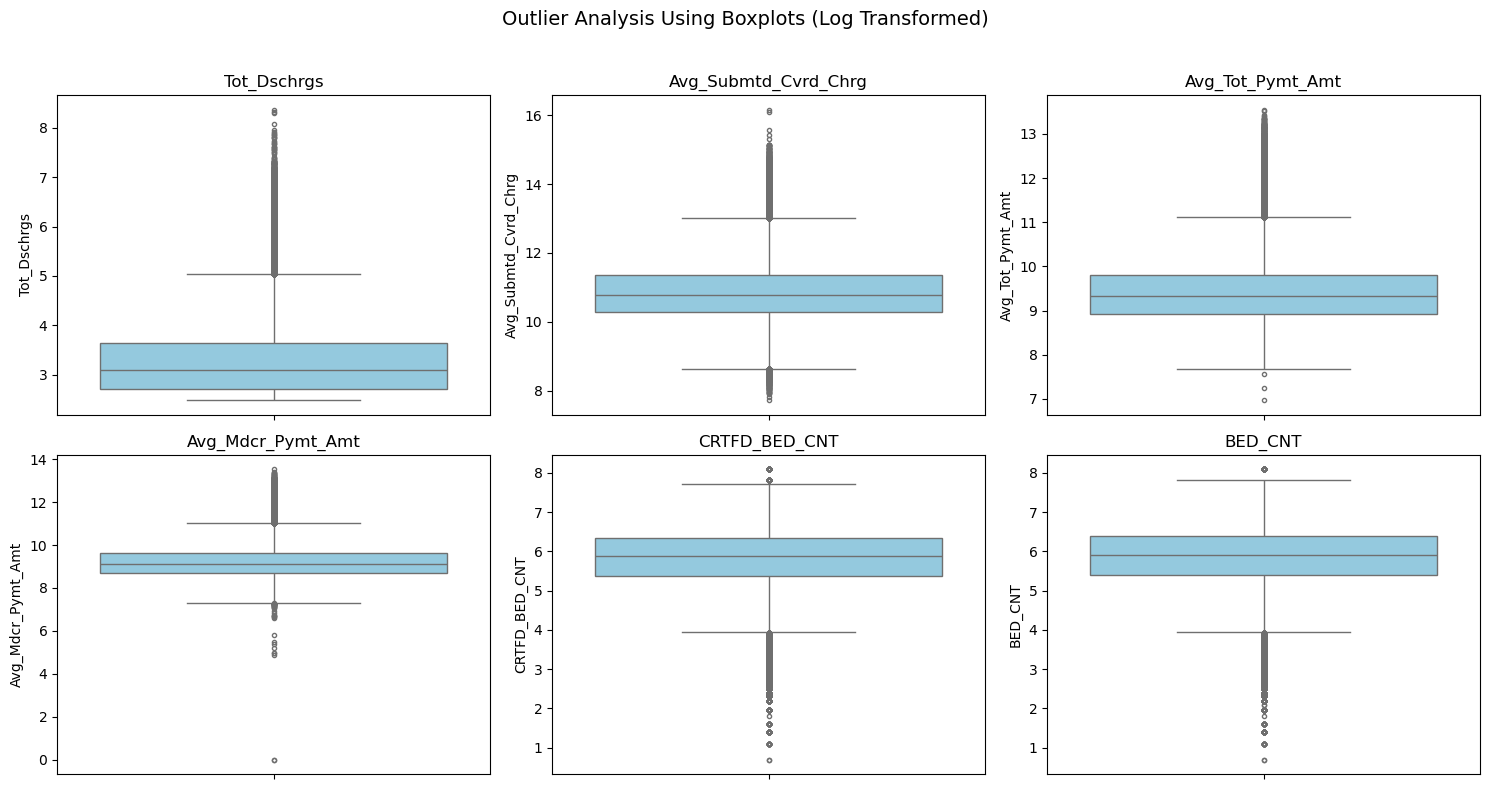

In [11]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Force 3 charts per row
n_cols = 3
n_rows = math.ceil(len(key_NumericCols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(key_NumericCols):
    ax = axes[i]
    sns.boxplot(
        y=df_medidata_log[col],
        ax=ax,
        color="skyblue",
        fliersize=3
    )
    ax.set_title(col)
    ax.set_xlabel("")

# Turn off unused subplots
for j in range(len(key_NumericCols), len(axes)):
    axes[j].axis("off")

plt.suptitle("Outlier Analysis Using Boxplots (Log Transformed)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [12]:
df_medidata.describe(exclude="number")
#Identify key categorical cols

,Rndrng_Prvdr_Org_Name,Rndrng_Prvdr_City,Rndrng_Prvdr_St,Rndrng_Prvdr_State_Abrvtn,Rndrng_Prvdr_RUCA_Desc,DRG_Desc,GNRL_CNTL_TYPE_CD,Ownership_Type,ownership_individual
count,1178407,1178407,1178407,1178407,1178407,1178407,1178407,1178407,1178407
unique,4073,1955,3549,51,15,622,17,3,9
top,Methodist Hospital,New York,525 East 68th Street,CA,Metropolitan area core: primary flow within an...,SEPTICEMIA OR SEVERE SEPSIS WITHOUT MV >96 HOU...,2,For-Profit,Partnership
freq,3094,10006,2626,96181,1008770,19303,618169,856516,661935


In [13]:

# Capture key categorical columns
key_CategoricalCols = [
    "Rndrng_Prvdr_State_Abrvtn",
    "Rndrng_Prvdr_RUCA_Desc",
    "DRG_Desc",
    "Ownership_Type",
    "ownership_individual"
]

print("Key Categorical Columns:", key_CategoricalCols)





Key Categorical Columns: ['Rndrng_Prvdr_State_Abrvtn', 'Rndrng_Prvdr_RUCA_Desc', 'DRG_Desc', 'Ownership_Type', 'ownership_individual']


## **CORE EDA**

### ***Year-by-Year Total Discharges (Line Chart)***

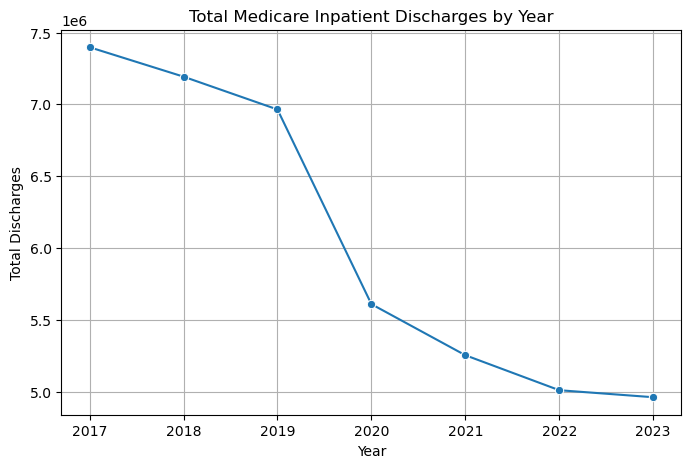

In [14]:
yearly_discharges = (
    df_medidata.groupby("Data_Year")["Tot_Dschrgs"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.lineplot(
    data=yearly_discharges,
    x="Data_Year",
    y="Tot_Dschrgs",
    marker="o"
)

plt.title("Total Medicare Inpatient Discharges by Year")
plt.xlabel("Year")
plt.ylabel("Total Discharges")
plt.grid(True)
plt.show()

### ***Total Discharges - By Geography***

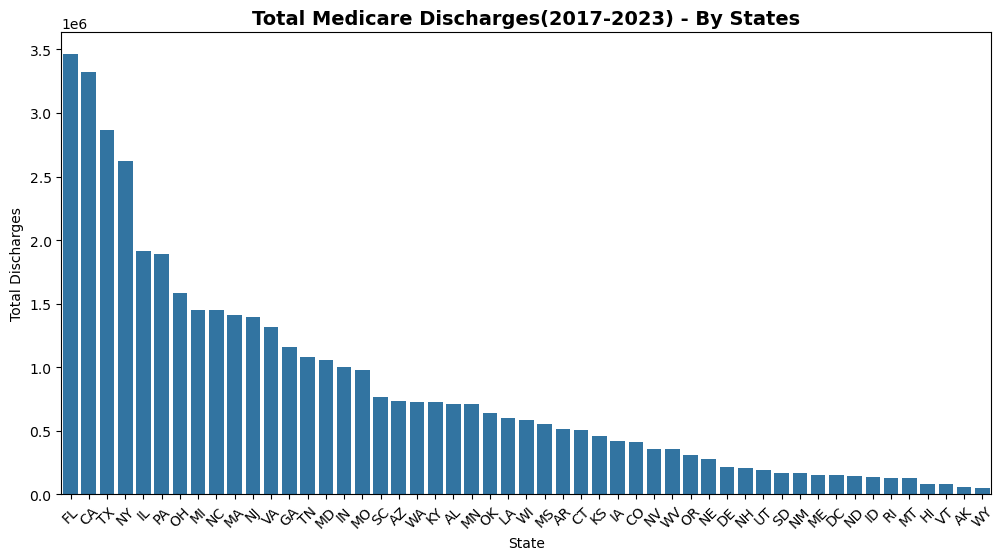

In [15]:
state_volume = (
    df_medidata.groupby("Rndrng_Prvdr_State_Abrvtn")["Tot_Dschrgs"]
    .sum()
    .sort_values(ascending=False)
    #.head(15)
)

plt.figure(figsize=(12,6))
sns.barplot(x=state_volume.index, y=state_volume.values)
plt.title("Total Medicare Discharges(2017-2023) - By States", fontsize=14, weight="bold")
plt.ylabel("Total Discharges")
plt.xlabel("State")
plt.xticks(rotation=45)
plt.show()


### ***By Ownership Type***

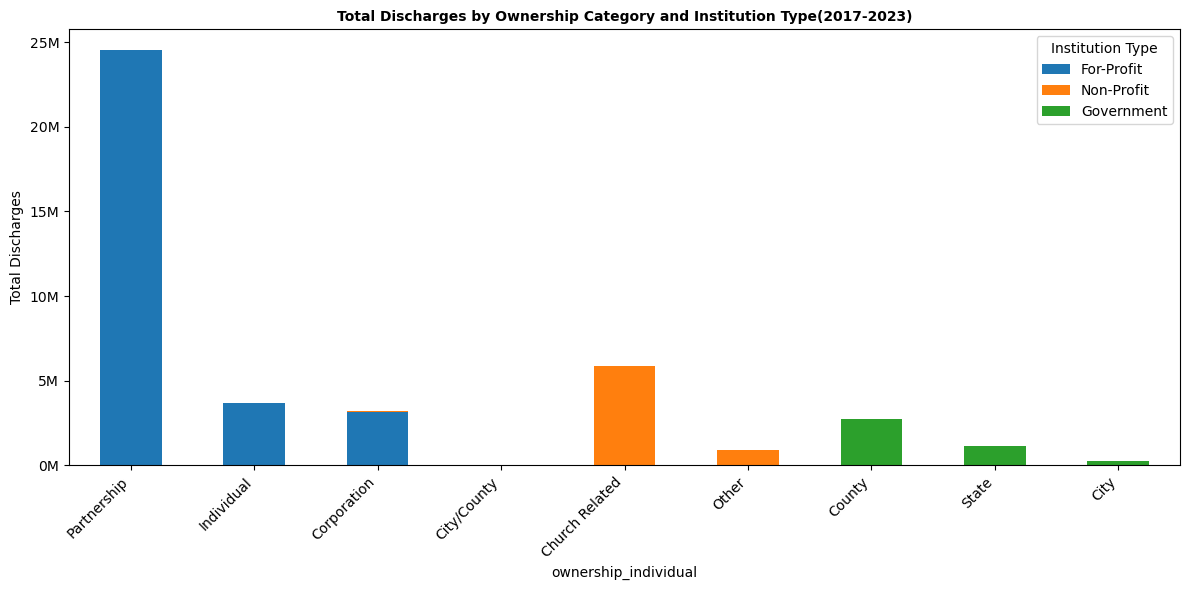

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import ticker


legend_order = ["For-Profit", "Non-Profit", "Government"]

# Sum Tot_Dschrgs instead of counting rows
ct = (
    df_medidata.pivot_table(
        index="ownership_individual",
        columns="Ownership_Type",
        values="Tot_Dschrgs",
        aggfunc="sum",
        fill_value=0
    )
)

# Ensure all legend columns exist + reorder
ct = ct.reindex(columns=legend_order, fill_value=0)

# Sort rows by stack priority (For-Profit then Non-Profit then Government)
ct = ct.sort_values(by=legend_order, ascending=[False, False, False])

ax = ct.plot(kind="bar", stacked=True, figsize=(12,6))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))  #10 million formatting

ax.set_title("Total Discharges by Ownership Category and Institution Type(2017-2023)", fontsize=10, weight="bold")
ax.set_xlabel("ownership_individual")
ax.set_ylabel("Total Discharges")

plt.xticks(rotation=45, ha="right")
plt.legend(title="Institution Type")
plt.tight_layout()
plt.show()


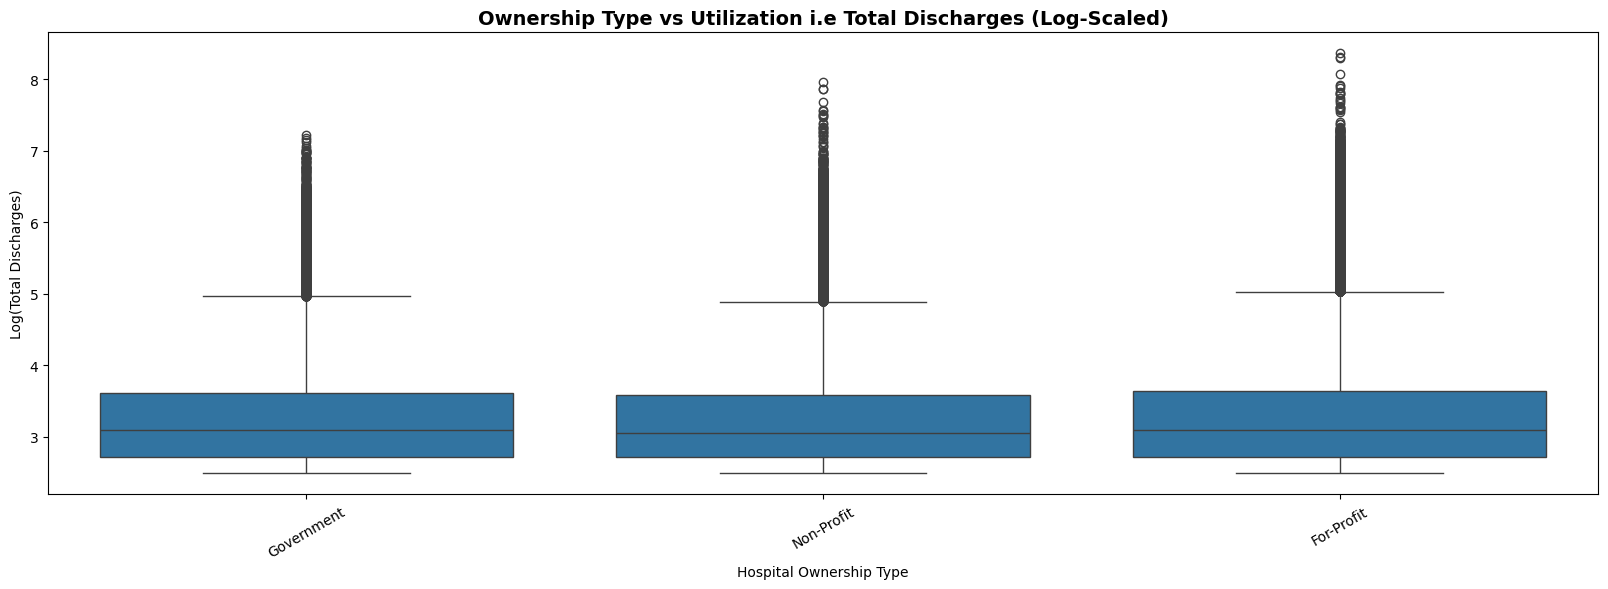

In [17]:
import numpy as np

df_medidata["Log_Discharges"] = np.log1p(df_medidata["Tot_Dschrgs"])

plt.figure(figsize=(20,6))

sns.boxplot(
    data=df_medidata,
    x="Ownership_Type",
    y="Log_Discharges"
)

plt.title("Ownership Type vs Utilization i.e Total Discharges (Log-Scaled)", fontsize=14, weight="bold")
plt.xlabel("Hospital Ownership Type")
plt.ylabel("Log(Total Discharges)")
plt.xticks(rotation=30)
plt.show()


### ***DRG Volume Bar Graph***

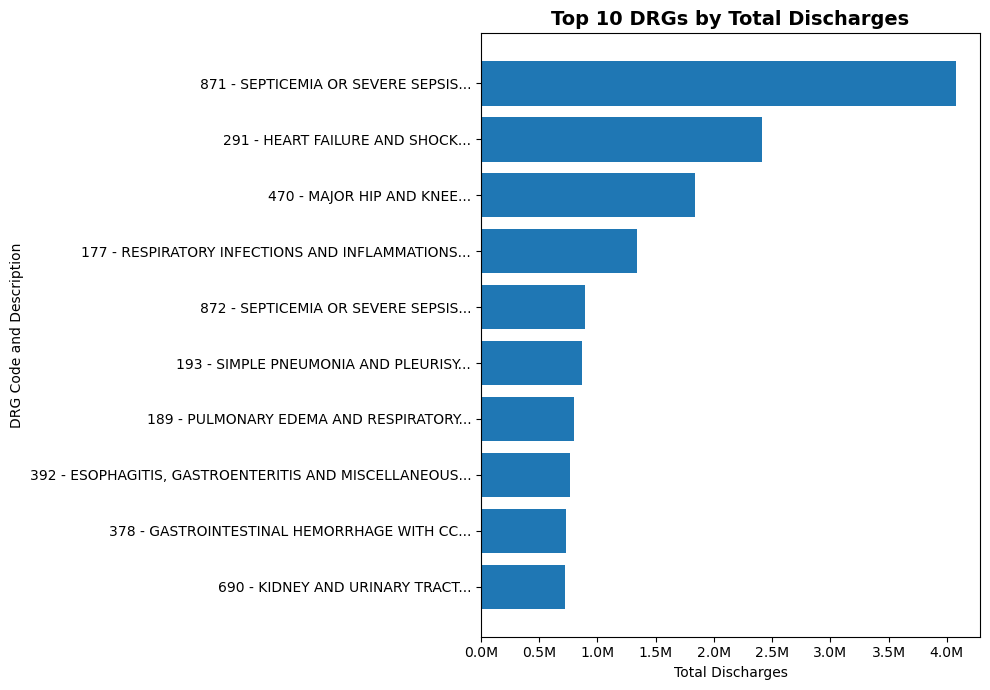

In [18]:
from matplotlib import ticker


top_drg = (
    df_medidata
    .groupby(["DRG_Cd", "DRG_Desc"], as_index=False)["Tot_Dschrgs"]
    .sum()
    .sort_values("Tot_Dschrgs", ascending=False)
    .head(10)
)

# Create short description (first 2 words)
top_drg["Short_Desc"] = (
    top_drg["DRG_Desc"]
    .str.split().str[:4]
    .str.join(" ")
)

# Combine DRG Code + Short Description
top_drg["Label"] = (
    top_drg["DRG_Cd"].astype(str) + " - " + top_drg["Short_Desc"] + "..."
)

plt.figure(figsize=(10,7))

plt.barh(top_drg["Label"], top_drg["Tot_Dschrgs"])

plt.gca().invert_yaxis()
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M')) #1 million formatting

# ---- Add title ----
plt.title("Top 10 DRGs by Total Discharges", fontsize=14, weight="bold")

# ---- Add axis labels ----
plt.xlabel("Total Discharges")
plt.ylabel("DRG Code and Description")

plt.tight_layout()
plt.show()



### Top 10 Most Costly DRGs (by Total Charges)

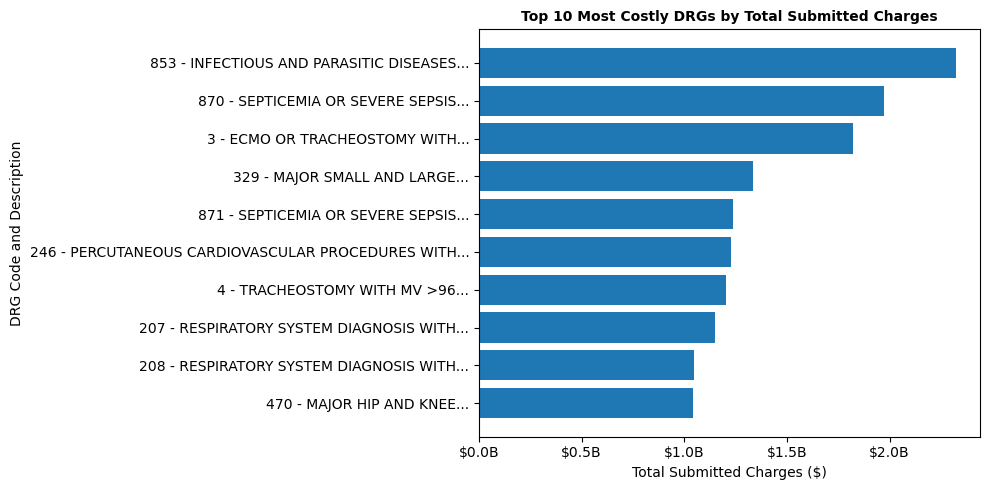

In [19]:
from matplotlib import ticker
import matplotlib.pyplot as plt

# Aggregate total submitted charges per DRG
top_costly_drg = (
    df_medidata
    .groupby(["DRG_Cd", "DRG_Desc"], as_index=False)["Avg_Submtd_Cvrd_Chrg"]
    .sum()
    .sort_values("Avg_Submtd_Cvrd_Chrg", ascending=False)
    .head(10)
)

# Short description
top_costly_drg["Short_Desc"] = (
    top_costly_drg["DRG_Desc"]
    .str.split().str[:4]
    .str.join(" ")
)

# Combine DRG Code + Short Description
top_costly_drg["Label"] = (
    top_costly_drg["DRG_Cd"].astype(str) + " - " +
    top_costly_drg["Short_Desc"] + "..."
)

plt.figure(figsize=(10,5))

plt.barh(
    top_costly_drg["Label"],
    top_costly_drg["Avg_Submtd_Cvrd_Chrg"]
)

plt.gca().invert_yaxis()

ax = plt.gca()
ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B')
)

plt.title("Top 10 Most Costly DRGs by Total Submitted Charges",
          fontsize=10, weight="bold")

plt.xlabel("Total Submitted Charges ($)")
plt.ylabel("DRG Code and Description")

plt.tight_layout()
plt.show()


### ***Scatter Plot: Charges vs Payments***
Whether Medicare consistently pays less than billed ? Whether high-charge hospitals behave differently?

- X-axis: `Avg_Submtd_Cvrd_Chrg` (what hospital billed)
- Y-axis: `Avg_Mdcr_Pymt_Amt` (what Medicare paid)


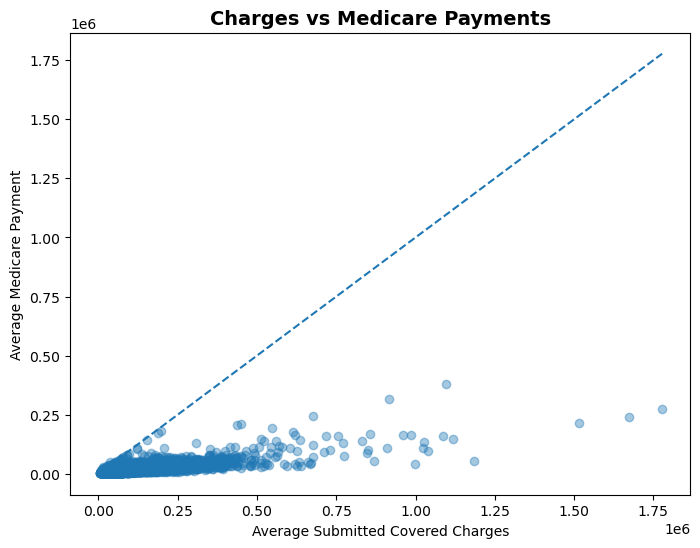

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sample_df = df_medidata.sample(10000, random_state=42) # sample 10000 records only for better visibility

plt.scatter(
    sample_df["Avg_Submtd_Cvrd_Chrg"],
    sample_df["Avg_Mdcr_Pymt_Amt"],
    alpha=0.4 # Adjust transparency for better visibility
)

# 45-degree line
max_val = max(sample_df["Avg_Submtd_Cvrd_Chrg"].max(),
              sample_df["Avg_Mdcr_Pymt_Amt"].max())

plt.plot([0, max_val], [0, max_val], linestyle='--')


plt.xlabel("Average Submitted Covered Charges")
plt.ylabel("Average Medicare Payment")
plt.title("Charges vs Medicare Payments", fontsize=14, weight="bold")
plt.show()


### ***Payment Gap Histogram***
- Payment Gap = `Avg_Submtd_Cvrd_Chrg` −  `Avg_Mdcr_Pymt_Amt`


In [21]:
df_medidata["Payment_Gap"] = (
    df_medidata["Avg_Submtd_Cvrd_Chrg"] -
    df_medidata["Avg_Mdcr_Pymt_Amt"]
)

df_medidata["Payment_Gap"] .describe().round(4) 

count    1.178407e+06
mean     6.152474e+04
std      8.331029e+04
min     -1.078771e+05
25%      2.158259e+04
50%      3.870958e+04
75%      7.153149e+04
max      9.667454e+06
Name: Payment_Gap, dtype: float64

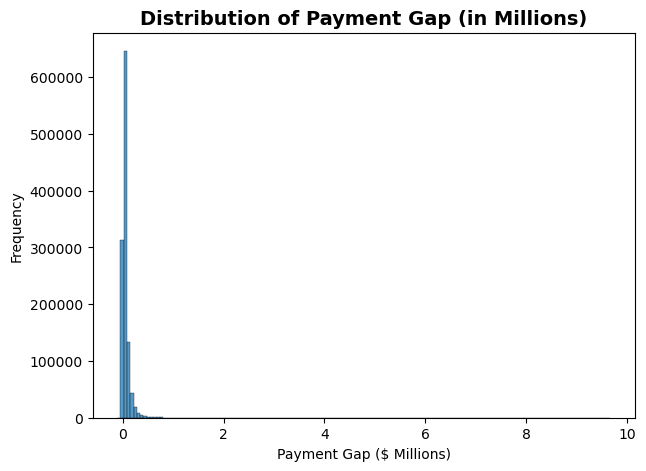

In [22]:
# Create payment gap column
from matplotlib.ticker import ScalarFormatter

# Convert to millions
payment_gap_millions = df_medidata["Payment_Gap"] / 1_000_000

plt.figure(figsize=(7,5))
sns.histplot(payment_gap_millions, bins=150)
plt.title("Distribution of Payment Gap (in Millions)", fontsize=14, weight="bold")
plt.xlabel("Payment Gap ($ Millions)")
plt.ylabel("Frequency")
plt.show()

- The distribution of the payment gap right-skewed, with the majority of observations are below $0.5 million and a small number of extreme outliers extending up to $10 million. 
- This indicates that  most hospitals have moderate charge-to-payment differences, a small subset of cases have payment inefficiency. 
- The presence of extreme outliers suggests potential structural pricing differences across specific DRGs or hospital types.

### ***Correlation chart***

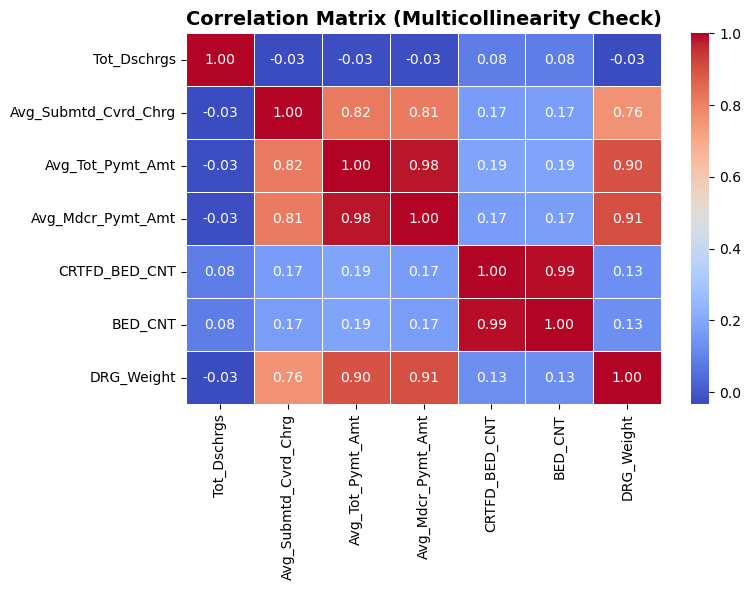

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = [
    "Tot_Dschrgs",
    "Avg_Submtd_Cvrd_Chrg",
    "Avg_Tot_Pymt_Amt",
    "Avg_Mdcr_Pymt_Amt",
    "CRTFD_BED_CNT",
    "BED_CNT",
    "DRG_Weight"
]

corr_matrix = df_medidata[numeric_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix (Multicollinearity Check)", fontsize=14, weight="bold")
plt.tight_layout()
plt.show()


A correlation matrix to assess multicollinearity among numerical predictors is created. Strong correlations were observed between payment-related variable
- Average Total Payment and Average Medicare Payment were highly correlated (0.98), meaning they contain nearly the same information.
- Certified Bed Count and Total Bed Count were also highly correlated (0.99), one of these will be dropped

one variable from each highly correlated pair will/might be removed during feature selection.
